# 項目：可視化帕默群島企鵝數據

## 分析目標

此數據分析報告的目的就是對帕默羣島上企鵝樣本的相關變量進行可視化，從而探索和分析種類、性別、所在島嶼等因素，與企鵝的身體屬性，包括體重、嘴峰長度和深度、鰭的長度，之間的關係。

## 簡介

簡介 原始數據Penguins.csv包括334個收集自南極洲帕爾默羣島的3個島嶼上的企鵝樣本，以及企鵝相關屬性數據，包括種類名、所在島、嘴峯長度、嘴峯深度、鰭長度、體重、性別。 Penguins.csv每列的含義如下：

species：企鵝的種類
island：企鵝所在島嶼
culmen_length_mm：企鵝嘴峰的長度（單位為毫米）
culmen_depth_mm：企鵝嘴峰的深度（單位為毫米）
flipper_length_mm：企鵝鰭的長度（單位為毫米）
body_mass_g：企鵝體重（單位為克）
sex：企鵝性別

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
penguins = pd.read_csv(r'C:\Users\USER\Desktop\penguins (1).csv')

In [17]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [60]:
#把有缺失值的欄位刪除(包含刪除性別".")
penguins['sex'] = penguins['sex'].replace(".", np.nan)
penguins_clean = penguins.dropna(how = 'any')
penguins_clean.head(10)
penguins_clean['sex'].value_counts

<bound method IndexOpsMixin.value_counts of 0        MALE
1      FEMALE
2      FEMALE
4      FEMALE
5        MALE
        ...  
338    FEMALE
340    FEMALE
341      MALE
342    FEMALE
343      MALE
Name: sex, Length: 333, dtype: object>

In [19]:
#設置色盤為pastel
sns.set_palette('pastel')

Adelie       146
Gentoo       120
Chinstrap     68
Name: species, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

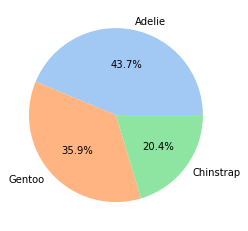

In [23]:
species_count = penguins_clean['species'].value_counts()
print(species_count)
#繪製圓餅圖
plt.pie(species_count, autopct = '%.1f%%', labels = species_count.index)
plt.show

樣本中Adelie的樣本最多，Chinstrap最少

Biscoe       164
Dream        123
Torgersen     47
Name: island, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

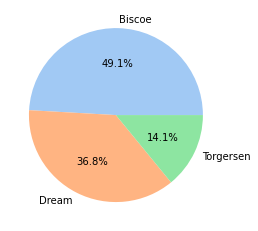

In [27]:
#企鵝所屬島嶼比例
island_count = penguins_clean['island'].value_counts()
print(island_count)
#繪製圓餅圖
plt.pie(island_count, autopct = '%.1f%%', labels = island_count.index)
plt.show

大約有一半的企鵝樣本來自Biscoe島嶼，其次是Dream，Torgerson島嶼最少

MALE      168
FEMALE    165
.           1
Name: sex, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

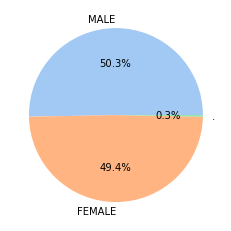

In [56]:
#性別比例
sex_count = penguins_clean['sex'].value_counts()
print(sex_count)
#繪製圓餅圖
plt.pie(sex_count, autopct = '%.1f%%', labels = sex_count.index)
plt.show

In [ ]:
男女比約各占一半，符合隨機抽樣預期

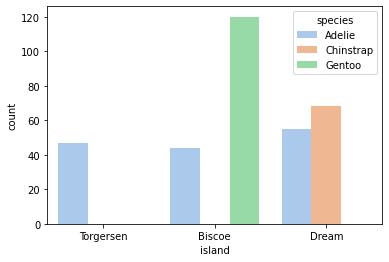

In [36]:
#不同島上企鵝種類數量
sns.countplot(data = penguins_clean, x='island', hue ='species')
plt.show()

由圖可知，Adelie在三座島上都有；Chinstrap只有在Dream有；Gentoo只有在Biscoe Island有

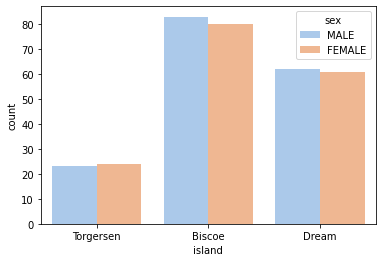

In [61]:
#不同島嶼企鵝性別數量(在此有發現一筆值為.之數據，回前面刪除)
sns.countplot(data = penguins_clean, x='island', hue ='sex')
plt.show()

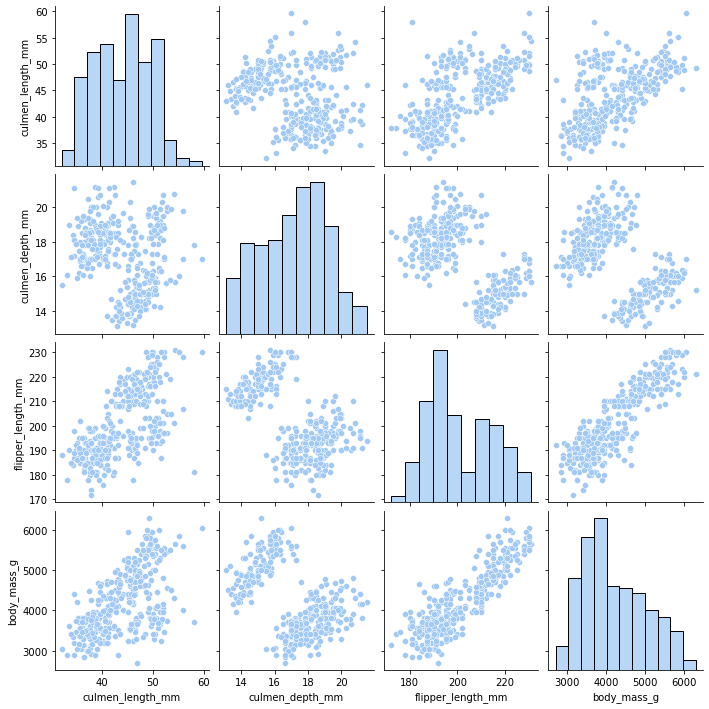

In [38]:
sns.pairplot(penguins_clean)
plt.show()

從上圖看，企鵝的嘴長、嘴深、鰭長度、體重皆不呈現常態分配，可能是因為樣本不夠大或者是有多組差異大的樣本數據

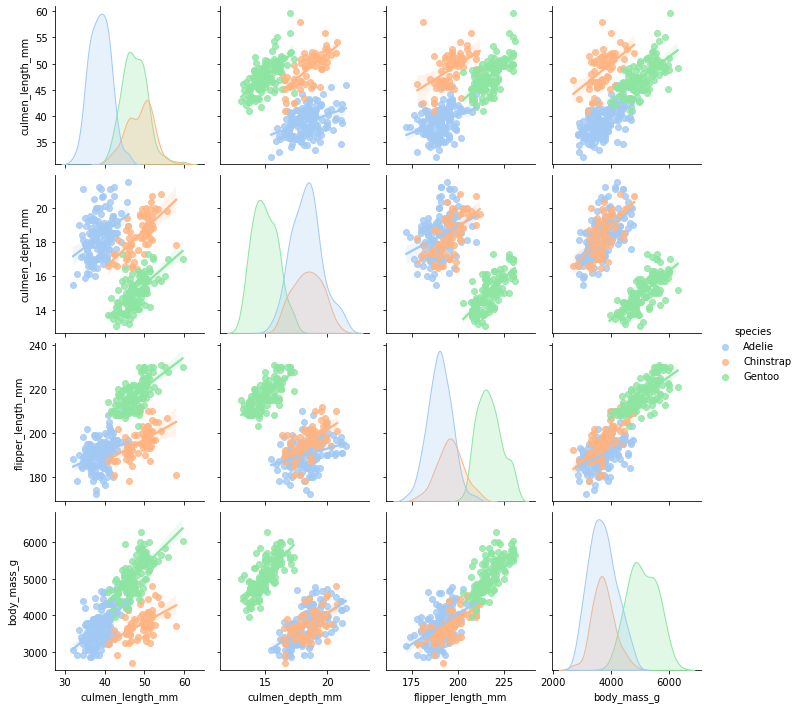

In [50]:
#依據種類查看數值之間的相關性
sns.pairplot(penguins_clean,hue = 'species', kind = 'reg')
plt.show()

In [ ]:
由上圖可知，各項數據分布基本都呈現正相關(EX:嘴峰越長，體重越重；鰭越短體重越輕....)
Gentoo的鰭長較長，體重較重，嘴峰深度較短

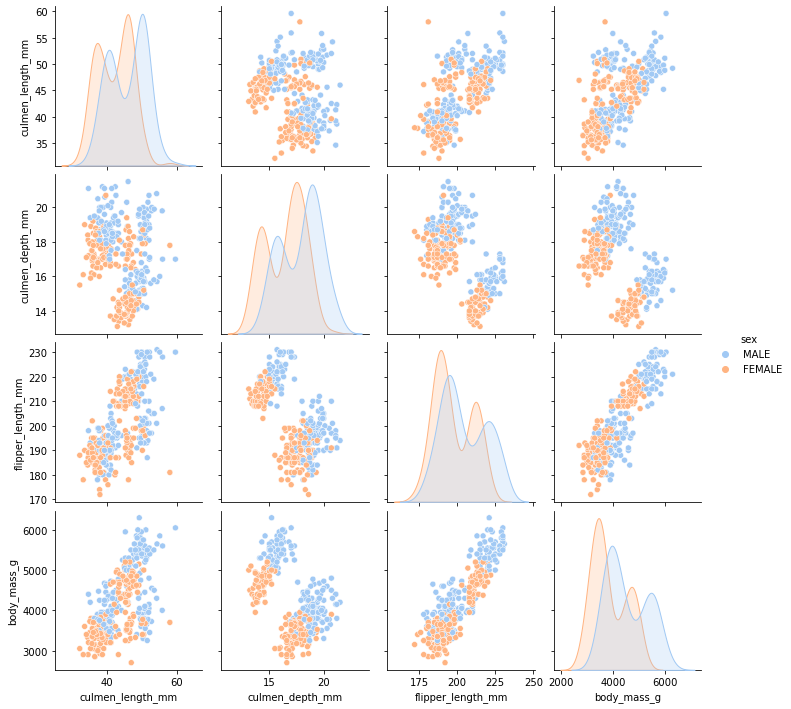

In [62]:
#依據性別查看數值之間的相關性
sns.pairplot(penguins_clean,hue = 'sex')
plt.show()

In [ ]:
雄性企鵝嘴長、嘴深、鰭長、體重均大於雌性企鵝